# Softmax 分类器练习

完成并提交此工作表（包括其输出和任何在工作表外的支持代码）作为你的作业提交。更多细节请参见课程网站上的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)。

在本练习中你将：

- 实现 Softmax 分类器的全向量化**损失函数**。
- 实现其**解析梯度**的全向量化表达式。
- 使用数值梯度**检查你的实现**。
- 使用验证集**调优学习率和正则化强度**。
- 用**SGD**优化损失函数。
- **可视化**最终学习到的权重。

<details><summary>英文原文</summary>

# Softmax Classifier exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights

</details>

In [15]:
# 运行本笔记本的一些设置代码。
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# 这是一些魔法命令，使 matplotlib 图像在笔记本内联显示
# 而不是在新窗口中显示。
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 设置图像默认大小
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# 还有一些魔法命令，使笔记本能自动重新加载外部 python 模块；
# 参考 http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## CIFAR-10 数据加载与预处理

<details><summary>英文原文</summary>

## CIFAR-10 Data Loading and Preprocessing

</details>

In [16]:
# 加载原始 CIFAR-10 数据。
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# 清理变量以防止多次加载数据（可能导致内存问题）
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# 做一个健壮性检查，打印训练和测试数据的大小。
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Clear previously loaded data.
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


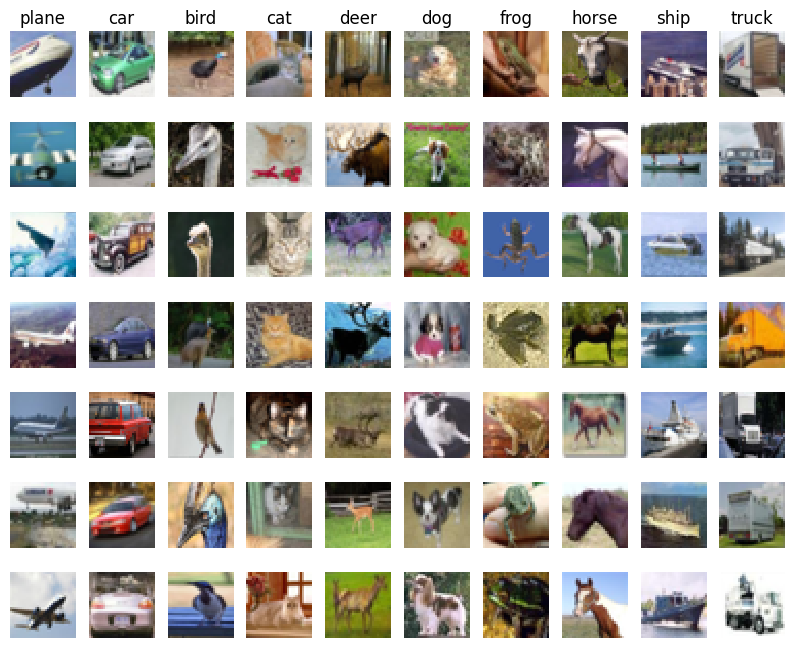

In [17]:
# 可视化数据集中的一些样本。
# 我们展示每个类别的部分训练图像样本。
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [18]:
# 将数据分为训练集、验证集和测试集。此外我们还会
# 创建一个小的开发集作为训练集的子集；
# 用于开发阶段以加快代码运行速度。
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# 验证集将是原始训练集中的 num_validation 个样本。
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# 训练集将是原始训练集中的前 num_train 个样本。
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# 我们还会创建一个开发集，是训练集的一个小子集。
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# 测试集是原始测试集的前 num_test 个样本。
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [19]:
# 预处理：将图像数据重塑为行向量
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# 做一个健壮性检查，打印数据的形状
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


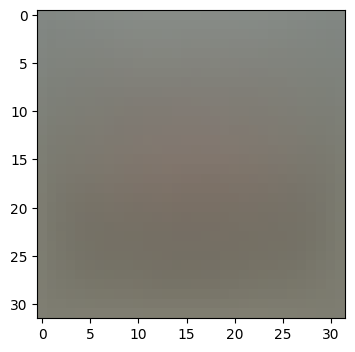

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [20]:
# 预处理：减去均值图像
# 第一步：根据训练数据计算均值图像
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # 打印部分元素
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # 可视化均值图像
plt.show()

# 第二步：从训练和测试数据中减去均值图像
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# 第三步：添加偏置维度（全为 1），这样分类器只需优化一个权重矩阵 W。
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax 分类器

本节的代码都写在 `cs231n/classifiers/softmax.py` 文件中。

如你所见，我们已经预填了 `softmax_loss_naive` 函数，它用 for 循环计算 softmax 损失函数。

<details><summary>英文原文</summary>

## Softmax Classifier

Your code for this section will all be written inside `cs231n/classifiers/softmax.py`.

As you can see, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

</details>

In [21]:
# 评估我们为你提供的朴素损失实现：
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# 生成一个随机的 Softmax 分类器权重矩阵，数值较小
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# 粗略健壮性检查，我们的损失应该接近 -log(0.1)。
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.434265
loss: 2.434265
sanity check: 2.302585


**内嵌问题 1**

为什么我们期望损失接近 -log(0.1)？请简要解释。

$\color{blue}{\textit 你的答案:}$ 在初始化时，权重矩阵W接近于零。对于任何输入样本，每个类别的分数都接近于零且彼此相等。每个类别的概率都为0.1，初始损失期望为-log(0.1)

<details><summary>英文原文</summary>

**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textit Your Answer:}$ *Fill this in*

</details>

上面函数返回的 `grad` 目前全为零。请推导并实现 softmax 损失函数的梯度，并在 `softmax_loss_naive` 函数内实现。你可以将新代码插入到现有函数中。

为了检查你是否正确实现了梯度，可以用数值方法估算损失函数的梯度，并与你计算的梯度进行比较。我们已为你提供了相关代码：

<details><summary>英文原文</summary>

The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

</details>

In [22]:
# 实现梯度后，重新计算并用我们提供的函数做梯度检查

# 在 W 处计算损失和梯度。
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# 在几个随机选定的维度上数值计算梯度，
# 并与你解析计算的梯度比较。所有维度上的数值应该几乎完全一致。
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# 再次做梯度检查，打开正则化项
# 你没有忘记正则化梯度吧？
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

数值梯度: 1.823257 解析梯度: 1.823257, 相对误差: 3.713906e-08
数值梯度: 6.223342 解析梯度: 6.223342, 相对误差: 1.196454e-09
数值梯度: 0.501018 解析梯度: 0.501018, 相对误差: 8.025558e-08
数值梯度: 0.639479 解析梯度: 0.639479, 相对误差: 4.192563e-08
数值梯度: 1.429706 解析梯度: 1.429706, 相对误差: 2.090993e-08
数值梯度: 1.747829 解析梯度: 1.747829, 相对误差: 9.845679e-09
数值梯度: 0.346509 解析梯度: 0.346508, 相对误差: 1.580862e-07
数值梯度: -3.932586 解析梯度: -3.932586, 相对误差: 2.903127e-09
数值梯度: 1.341020 解析梯度: 1.341020, 相对误差: 1.867004e-09
数值梯度: 2.368408 解析梯度: 2.368408, 相对误差: 2.248435e-08
数值梯度: -1.110506 解析梯度: -1.110506, 相对误差: 2.738762e-08
数值梯度: 1.037214 解析梯度: 1.037214, 相对误差: 7.140454e-08
数值梯度: 3.476475 解析梯度: 3.476475, 相对误差: 2.186742e-08
数值梯度: 2.032781 解析梯度: 2.032781, 相对误差: 3.325127e-08
数值梯度: 3.119484 解析梯度: 3.119484, 相对误差: 2.584639e-09
数值梯度: 0.426326 解析梯度: 0.426326, 相对误差: 6.254368e-08
数值梯度: 1.736725 解析梯度: 1.736725, 相对误差: 3.893063e-08
数值梯度: -3.807739 解析梯度: -3.807739, 相对误差: 4.432474e-09
数值梯度: 0.687961 解析梯度: 0.687961, 相对误差: 1.221641e-08
数值梯度: 2.859038 解析梯度: 2.859038, 相对误差: 2.21652

**内嵌问题 2**

虽然 gradcheck 对 softmax 损失很可靠，但对于 SVM 损失，偶尔某个维度的 gradcheck 结果可能不完全匹配。造成这种差异的原因可能是什么？是否需要担心？请举一个一维情况下 SVM 损失梯度检查可能失败的简单例子？改变 margin 会如何影响这种情况发生的频率？

注意，对于样本 $(x_i, y_i)$，SVM 损失定义为：$$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ 其中 $j$ 遍历所有非正确类别 $y_i$，$s_j$ 表示第 $j$ 类的分类器得分。$\Delta$ 是一个标量间隔。更多信息见[这里](https://cs231n.github.io/linear-classify/)的“多类支持向量机损失”。

*提示：SVM 损失函数严格来说并不可微分。*

$\color{blue}{\textit 你的答案:}$ *请填写*

<details><summary>英文原文</summary>

**Inline Question 2**

Although gradcheck is reliable softmax loss, it is possible that for SVM loss, once in a while, a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a svm loss gradient check could fail? How would change the margin affect of the frequency of this happening?

Note that SVM loss for a sample $(x_i, y_i)$ is defined as: $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ where $j$ iterates over all classes except the correct class $y_i$ and $s_j$ denotes the classifier score for $j^{th}$ class. $\Delta$ is a scalar margin. For more information, refer to 'Multiclass Support Vector Machine loss' on [this](https://cs231n.github.io/linear-classify/) page.

*Hint: the SVM loss function is not strictly speaking differentiable.*

$\color{blue}{\textit Your Answer:}$ *fill this in.*  

</details>

In [23]:
# 接下来实现 softmax_loss_vectorized 函数；目前只需计算损失，
# 梯度稍后实现。
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# 损失应该一致，但你的向量化实现应该快得多。
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.434265e+00 computed in 0.027887s
Vectorized loss: 2.434265e+00 computed in 0.002078s
difference: -0.000000


In [24]:
# 完成 softmax_loss_vectorized 的实现，并用向量化方式计算损失函数的梯度。

# 朴素实现和向量化实现应该一致，但
# 向量化版本仍然快得多。
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# 损失是一个数值，所以比较两种实现的值很容易。梯度是一个矩阵，
# 所以我们用 Frobenius 范数比较它们。
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.029556s
Vectorized loss and gradient: computed in 0.002122s
difference: 0.000000


### 随机梯度下降（SGD）

现在我们有了向量化且高效的损失和梯度表达式，并且梯度与数值梯度一致。因此我们可以用 SGD 最小化损失。本部分代码写在 `cs231n/classifiers/linear_classifier.py` 文件中。

<details><summary>英文原文</summary>

### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

</details>

In [34]:
# 在 linear_classifier.py 文件中实现 SGD，
# LinearClassifier.train() 函数，然后运行下面的代码。
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 772.579864
iteration 100 / 1500: loss 283.906636
iteration 200 / 1500: loss 105.197303
iteration 300 / 1500: loss 39.766783
iteration 400 / 1500: loss 15.938203
iteration 500 / 1500: loss 7.134592
iteration 600 / 1500: loss 3.951060
iteration 700 / 1500: loss 2.732605
iteration 800 / 1500: loss 2.362046
iteration 900 / 1500: loss 2.141044
iteration 1000 / 1500: loss 2.162281
iteration 1100 / 1500: loss 2.046771
iteration 1200 / 1500: loss 2.045954
iteration 1300 / 1500: loss 2.107718
iteration 1400 / 1500: loss 2.080261
That took 3.283592s


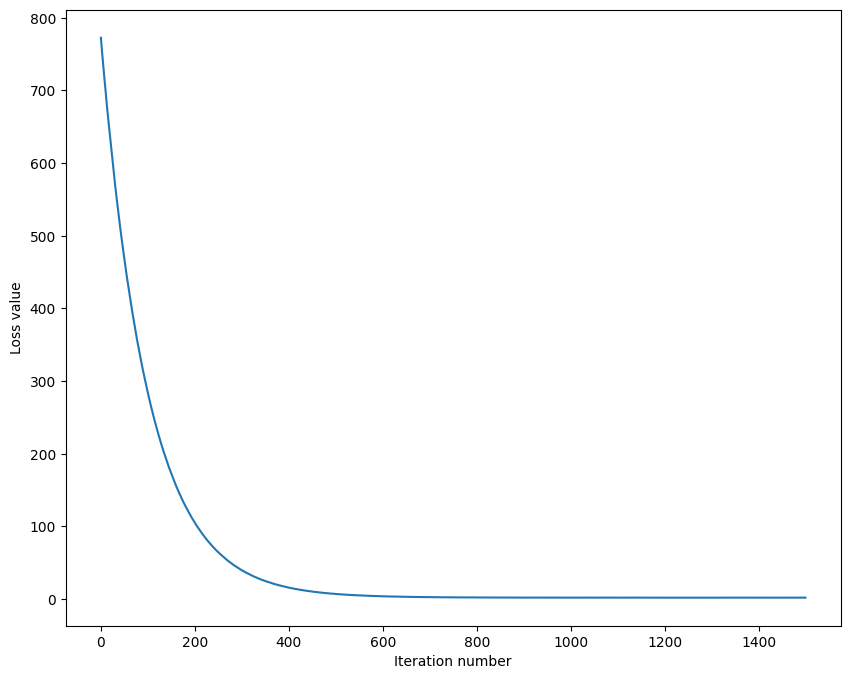

In [35]:
# 一个有用的调试策略是绘制损失随迭代次数的变化曲线：
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [36]:
# 编写 LinearClassifier.predict 函数，并在训练集和验证集上评估性能
# 你应该能在验证集上得到约 0.34 的准确率（> 0.33）。
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.325959
validation accuracy: 0.340000


In [37]:
# 保存训练好的模型用于自动评分。
softmax.save("softmax.npy")

softmax.npy saved.


In [38]:
# 用验证集调优超参数（正则化强度和学习率）。你应该尝试不同范围的学习率和正则化强度；
# 如果你仔细调参，应该能在验证集上得到约 0.365 的准确率（> 0.36）。

# 注意：在超参数搜索过程中可能会看到运行时/溢出警告。
# 这可能是极端值导致的，不是 bug。

# results 是一个字典，键为 (learning_rate, regularization_strength) 元组，
# 值为 (training_accuracy, validation_accuracy) 元组。准确率即正确分类样本的比例。
results = {}
best_val = -1   # 目前见过的最高验证准确率。
best_softmax = None # 达到最高验证准确率的 Softmax 对象。

################################################################################
# TODO:                                                                        #
# 编写代码，通过在验证集上调参选择最佳超参数。对于每组超参数，训练一个 Softmax，         #
# 在训练集和验证集上计算准确率，并存入 results 字典。此外，将最佳验证准确率存入 best_val， #
# 达到该准确率的 Softmax 对象存入 best_softmax。                                 #
#                                                                              #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################

# 仅供参考。你可以根据需要修改这些超参数
learning_rates = [1e-7, 5e-7]
regularization_strengths = [2.5e4, 5e4]

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        # 训练模型
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg,
                      num_iters=1500, verbose=False)
        
        # 在训练集和验证集上进行预测
        y_train_pred = softmax.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        
        y_val_pred = softmax.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        
        # 存储结果
        results[(lr, reg)] = (train_accuracy, val_accuracy)
        
        # 如果当前模型的验证准确率最高，则更新最佳模型
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax


# 打印结果。
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.331816 val accuracy: 0.344000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.312531 val accuracy: 0.327000
lr 5.000000e-07 reg 2.500000e+04 train accuracy: 0.326163 val accuracy: 0.347000
lr 5.000000e-07 reg 5.000000e+04 train accuracy: 0.300714 val accuracy: 0.317000
best validation accuracy achieved during cross-validation: 0.347000


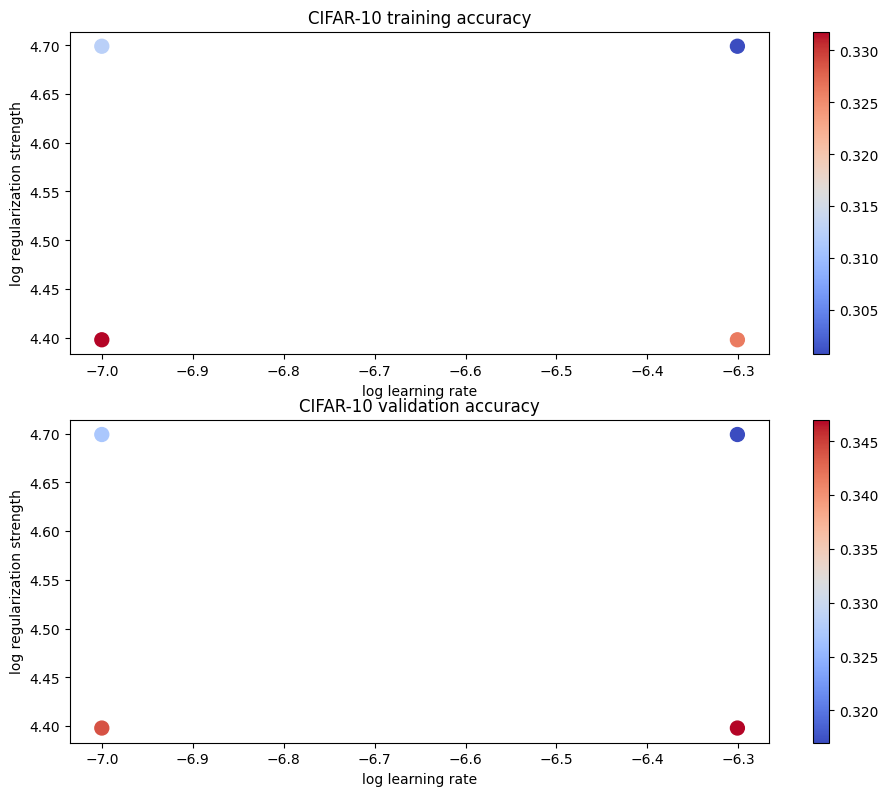

In [39]:
# 可视化交叉验证结果
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# 绘制训练准确率
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# 绘制验证准确率
colors = [results[x][1] for x in results] # 默认 marker 大小为 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [40]:
# 在测试集上评估最佳 softmax
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.334000


In [41]:
# 保存最佳 softmax 模型
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


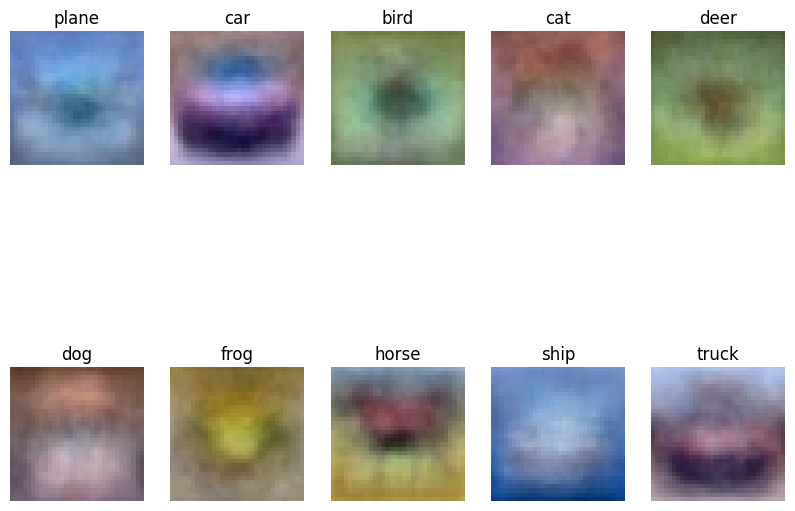

: 

In [ ]:
# 可视化每个类别学习到的权重。
# 根据你的学习率和正则化强度选择，这些权重可能
# 好看也可能不好看。
w = best_softmax.W[:-1,:] # 去掉偏置
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # 将权重缩放到 0 到 255 之间
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**内嵌问题 3**

描述你可视化的 Softmax 分类器权重是什么样的，并简要解释为什么会这样。

$\color{blue}{\textit 你的答案:}$ Softmax 分类器权重是10张模糊的图片，模型会去拟合训练数据，每张图片看起来像是该类别所有样本的平均值，效果比SVM权重要平滑。

<details><summary>英文原文</summary>

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textit Your Answer:}$ *fill this in*  

</details>

**内嵌问题 4** - *判断对错*

假设整体训练损失定义为所有训练样本的单点损失之和。可能添加一个新样本到训练集会改变 softmax 损失，但 SVM 损失保持不变。

$\color{blue}{\textit 你的答案:}$ 正确 (True)


$\color{blue}{\textit 你的解释:}$
对于SVM，假如添加一个新的数据点，并且数据点已经被当前的权重矩阵正确分类，分数满足SVM的要求。在这种情况下，该数据点的损失为0，因此总的损失保持不变。
对于Softmax分类器，计算出的概率总是小于1，因此新的数据点会产生一个非零的损失值，从而改变总的损失。

<details><summary>英文原文</summary>

**Inline Question 4** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.

$\color{blue}{\textit Your Answer:}$ True


$\color{blue}{\textit Your Explanation:}$
Let's assume the new data point is correctly classified by the current model with a score margin greater than $\Delta$ (i.e., the score of the correct class is greater than that of any incorrect class by at least the margin). In this case, the SVM loss for this individual data point is exactly zero. Consequently, the total SVM loss (sum of losses) remains unchanged.

However, for the Softmax classifier, the loss is $-\log(P(\text{correct class}))$. Since the probability $P$ is always strictly less than 1 (with finite weights), the loss is strictly greater than 0. Therefore, adding this data point will contribute a positive value to the total loss, thereby changing (increasing) the total Softmax loss.

</details>